Saving inspection plot to rdm_inspection_plot.png...


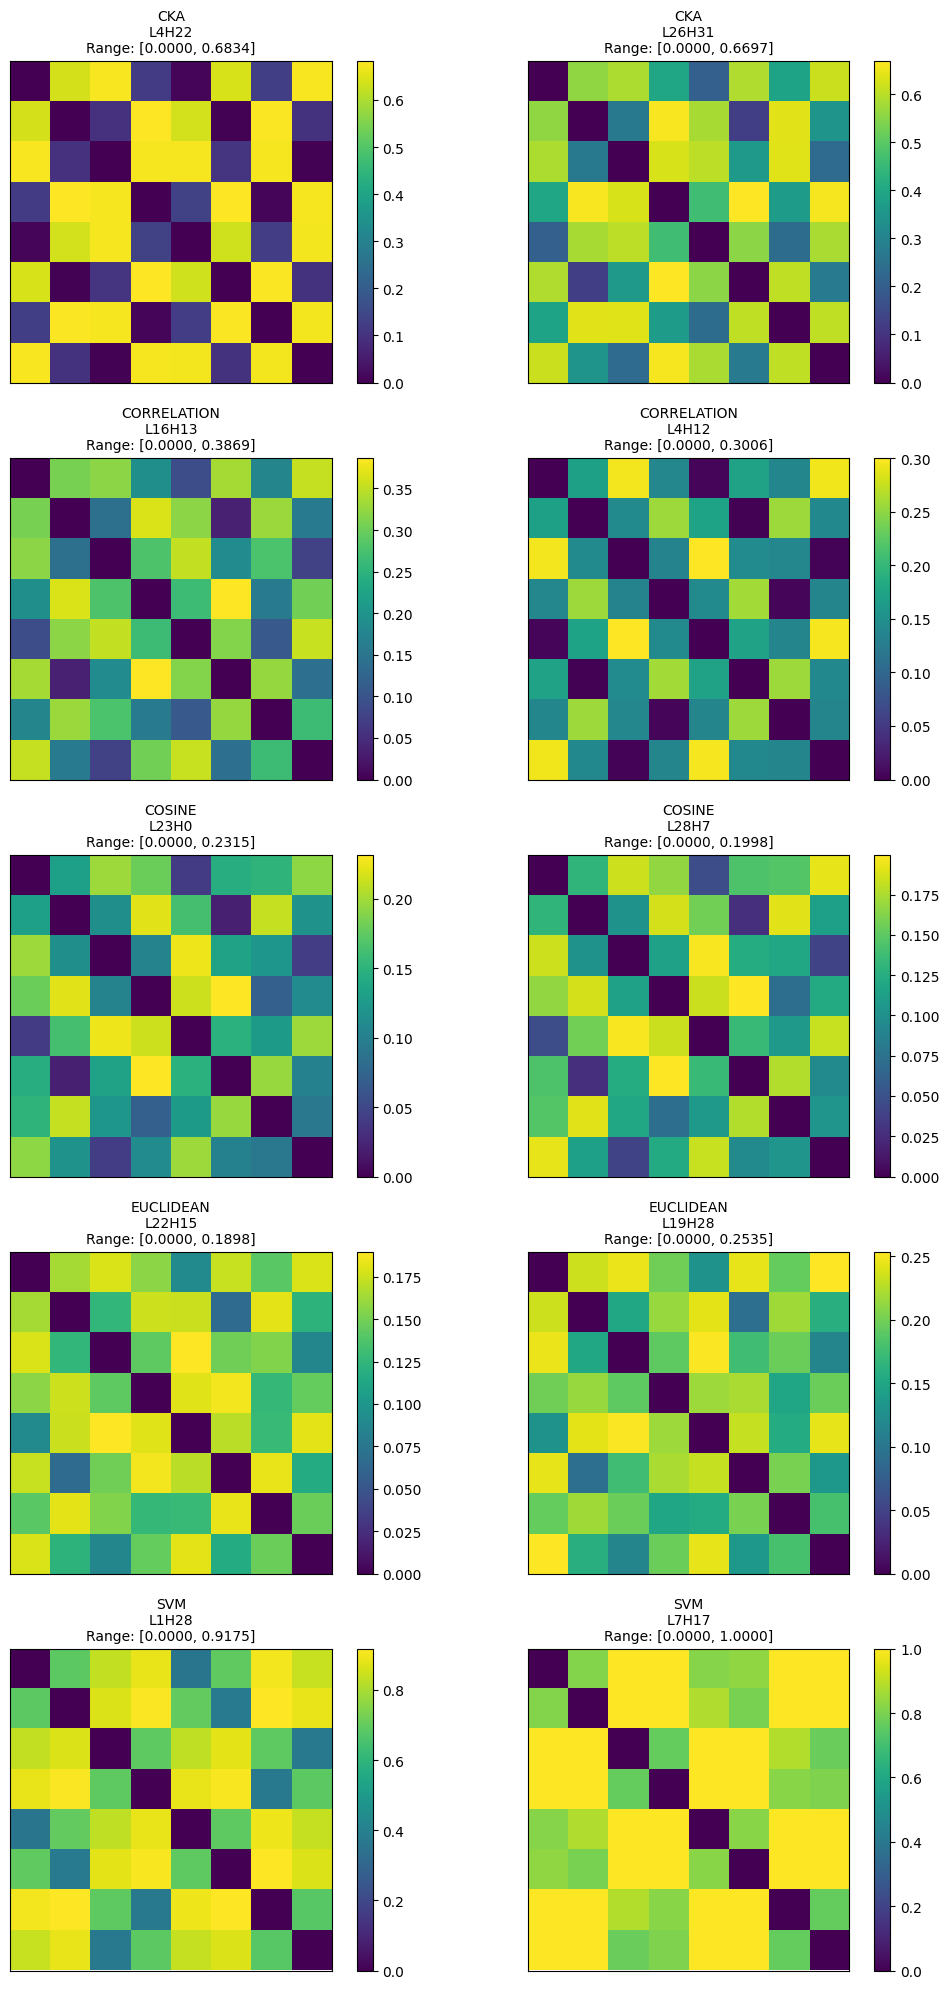

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

RDM_ROOT = Path("data/ToM_Data/rdm")
METRICS = ["cka", "correlation", "cosine", "euclidean", "svm"]
SAMPLES_PER_METRIC = 2
OUTPUT_FILE = "rdm_inspection_plot.png"


def inspect_and_plot():
    # 创建 5行 x 2列 的画布
    fig, axes = plt.subplots(len(METRICS), SAMPLES_PER_METRIC, figsize=(12, 20))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)

    for row_idx, metric in enumerate(METRICS):
        metric_dir = RDM_ROOT / metric

        if not metric_dir.exists():
            print(f"Skipping {metric}: Directory not found.")
            continue

        # 获取所有 L*H* 子文件夹
        subdirs = [p for p in metric_dir.iterdir() if p.is_dir() and p.name.startswith("L")]

        if not subdirs:
            print(f"Skipping {metric}: No subdirectories found.")
            continue

        # 随机抽取 2 个子文件夹 (如果不足2个则全取)
        k = min(len(subdirs), SAMPLES_PER_METRIC)
        selected_folders = random.sample(subdirs, k)

        for col_idx, folder in enumerate(selected_folders):
            ax = axes[row_idx, col_idx]
            file_path = folder / "avg_rdm.npy"

            if not file_path.exists():
                ax.text(0.5, 0.5, "File Not Found", ha='center')
                continue

            # 加载数据
            data = np.load(file_path)

            # 绘制热力图
            im = ax.imshow(data, cmap='viridis', interpolation='nearest')

            # 设置标题：显示指标、层头信息、数值范围
            ax.set_title(f"{metric.upper()}\n{folder.name}\nRange: [{data.min():.4f}, {data.max():.4f}]", fontsize=10)

            # 添加颜色条，方便观察数值大小
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # 移除刻度标签以保持整洁 (8x8矩阵看结构即可)
            ax.set_xticks([])
            ax.set_yticks([])

    print(f"Saving inspection plot to {OUTPUT_FILE}...")
    plt.tight_layout()
    plt.savefig(OUTPUT_FILE)
    plt.show()


if __name__ == "__main__":
    inspect_and_plot()